# Gasoline RVP Seasonality — a quantitative teardown 🔬
### Per-year Welch panel on the RB−CL excess · Bonferroni month table · window/halves robustness · the paired holder-vs-splice roll-gap test · costs on the investable legs · a 20-seed planted-seasonal control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Curve_prices_it%3F: Confirmed](https://img.shields.io/badge/Curve_prices_it%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim is a **statute** (40 CFR 1090.215: summer-RVP fuel at refineries/terminals by May 1, winter blend legal after Sept 15), so the test design is a *dated-calendar* test on the gasoline-minus-crude spread — and a second, sharper test of whether the futures curve pre-prices the date.

> ⚠️ **Construction note (load-bearing).** Yahoo `RB=F`/`CL=F` are **spliced front-month chains** — roll jumps included, earned by nobody. The Signal axis reads the splice as a **spot-price proxy**, labelled as such everywhere; the Tradability and third axes read `UGA`, the real holder. No survivorship (two futures chains + one live ETF, not a survivor basket). Real data: yfinance daily closes 2005→2026, as-of **2026-06-30**, fingerprint `ef905dc22f3c` — numbers frozen in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gasoline_rvp_seasonality import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    MRET = data.monthly_returns(PX)
    EX = st.excess_series(MRET)          # log(1+RB) - log(1+CL), spliced chains = spot proxy
else:
    PX = MRET = EX = None
print("real cache present:", HAVE_REAL,
      "| monthly excess obs:", (0 if EX is None else len(EX)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'asof': '2026-06-30', 'n_daily': 5412, 'n_excess': 257, 'win_mean': 3.77, 'rest_mean': -1.22, 'gap': 4.98, 'welch_years': 6.2, 'win_sum': 11.3, 't_win': 5.1, 'hit': 90.5, 'n_years': 21, 'welch_pooled': 4.23, 'n_pooled_w': 66, 'n_pooled_r': 191, 'months': [('Jan', 0.57, 0.31, 21), ('Feb', 1.34, 0.88, 22), ('Mar', 8.62, 5.34, 22), ('Apr', 1.72, 0.95, 22), ('May', -0.39, -0.26, 22), ('Jun', -1.54, -1.21, 22), ('Jul', 0.71, 0.59, 21), ('Aug', -0.5, -0.19, 21), ('Sep', -6.88, -3.12, 21), ('Oct', -2.82, -1.67, 21), ('Nov', 0.1, 0.09, 21), ('Dec', 0.79, 0.73, 21)], 'sep_mean': -6.88, 'sep_t': -3.12, 'sep_hit': 85.7, 'robust': [('Mar only', 8.78, 5.22, 5.61, 90), ('Mar-Apr', 10.14, 6.0, 6.8, 90), ('Feb-Apr', 11.3, 5.1, 6.2, 90), ('Feb-May', 10.91, 5.22, 6.38, 90)], 'halves': [('2005-2015', 9.6, 2.77, 11), ('2016-2025', 13.18, 4.81, 10)], 'roll_chain': 16.08, 'roll_holder': 5.68, 'roll_gap': -10.4, 'roll_t': -8.06, 'roll_neg': 100, 'roll_n': 18, 'sep_chain': -7.96, 'sep_holder': -1.58, 'sep_gap': 6.38, 'sep_gap_t': 4.95, 'inv_win_sum': -0.18, 'inv_t': -0.07, 'inv_hit': 47.1, 'inv_n': 17, 'inv_welch': -0.74, 'inv_sep': -0.02, 'inv_sep_t': -0.01, 'overlay': [(5.0, 9.45, 9.35, 1.48), (10.0, 9.45, 9.25, 1.46), (20.0, 9.45, 9.05, 1.43)], 'overlay_xcash': 8.91, 'overlay_xcash_t': 1.41, 'overlay_hit': 72.2, 'overlay_n': 18, 'syn_null': (-0.22, -0.24, 0.16, 0.03, 0.16), 'syn_plant': (4.61, 8.76, -2.76, -5.97, -42.35), 'fingerprint': 'ef905dc22f3c'}


real cache present: True | monthly excess obs: 257


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Feb–Apr window **+11.30%** cumulative excess (Welch **t = 6.20** across 21 yearly pairs, one-sample t = 5.10, hit 90.5%); only Mar (t = +5.34) and Sep (t = -3.12) survive Bonferroni ×12 — the statute's own months. |
| **Tradability** | `MIRAGE` | Investable crack (UGA−CL) Feb–Apr: **-0.18%/window, t = -0.07** (n = 17); roll gap **-10.40%/window** (t = -8.06), negative 18/18 years; long-only UGA overlay t = 1.46 net. |
| **Curve prices it?** | `CONFIRMED` | Paired holder-minus-splice gap **-10.40%** in the run-up (t = **-8.06**) and **+6.38%** giveback in Sep (t = +4.95). |

> 💡 In plain words: the law is on the tape, loudly and on the right dates — and the futures curve pays itself the whole thing before you arrive.

## 1 · The claim, steelmanned

Let $x_m = \log(1+r^{RB}_m) - \log(1+r^{CL}_m)$ — the monthly log-excess of the RBOB front chain over the WTI front chain (dollar-neutral, monthly rebalanced; the oil level nets out). The statute predicts a **dated** pattern:

- **H₁ (run-up).** $E[x_m] > 0$ for $m \in$ {Feb, Mar, Apr} — the transition into the May-1 refinery/terminal deadline.
- **H₂ (switch-back).** $E[x_m] < 0$ for Sep — winter blend legal after Sep 15.
- **H₃ (curve pricing).** For a real front-month holder $H$ (UGA) vs the spliced chain $S$: $\sum_{win}(\log(1+r^H) - \log(1+r^S)) < 0$ — the roll pays the seasonal away.

We find **H₁ and H₂ decisively supported** (Welch t = 6.20 across years; Mar and Sep the only Bonferroni survivors) and **H₃ decisively supported too** (gap t = −8.06, negative 18/18) — which is exactly why the *tradable* version of H₁ is dead.

## 2 · So what? — what rides on each answer

The per-year panel is the honest unit: each year contributes **one** window mean and one rest mean, so 66 pooled window months can't masquerade as 66 independent observations (monthly serial correlation inside a window year is absorbed into the yearly unit; annual observations of a monthly-rebalanced spread are essentially serially uncorrelated, so the plain Welch/one-sample t across ~21 years is the right statistic — no HAC lag choice to snoop). The month table gets a **Bonferroni ×12** bar because testing 12 months is 12 tests. The third axis is **paired** (same year, same window, holder minus chain), which removes the oil-level variance entirely — hence its enormous t.

Execution lag: the calendar is a **statute known years in advance**; entries use the prior month-end close. One lag, documented, trivially satisfied.

## 3 · How we'd know — the protocol

- **Tape.** yfinance daily closes: `RB=F`, `CL=F`, `UGA`, `^IRX`; 5,412 rows, 2005-01-03 → 2026-06-30 (as-of; partial month dropped); 257 monthly excess obs; UGA from 2008-02.
- **Signal.** $x_m$ on the spliced chains (spot proxy, labelled). Primary: **Welch t across per-year pairs** (window mean vs rest mean). Secondary: one-sample t of per-year window sums; pooled-months Welch; per-month table with Bonferroni ×12 (|t| ≥ ~3.0).
- **Robustness.** Window variants {Mar}, {Mar,Apr}, {Feb–Apr}, {Feb–May}; halves split 2005–2015 / 2016–2025.
- **Third axis.** Paired per-year holder-minus-splice window gap (UGA vs RB=F), run-up and September.
- **Tradability.** (a) investable crack = UGA−CL excess, same panel machinery; (b) long-only UGA Feb–Apr overlay, one round trip/yr, **5/10/20 bps one-way × NAV**, plus net-of-window-T-bill (excess-vs-cash; `^IRX`). Long-only ⇒ no borrow.
- **Control.** Synthetic world with planted `amp` (window seasonal, mirrored −amp in Sep) and planted `roll_drag` on the holder; **mean t over 20 seeds** (no single-seed baselines); null must stay quiet.

## 4 · The teardown

### 4a · The month table and its Bonferroni bar

Twelve one-sample t's, so the honest bar is |t| ≥ ~3.0. If the statute is driving, the survivors should be March and September — and only those.

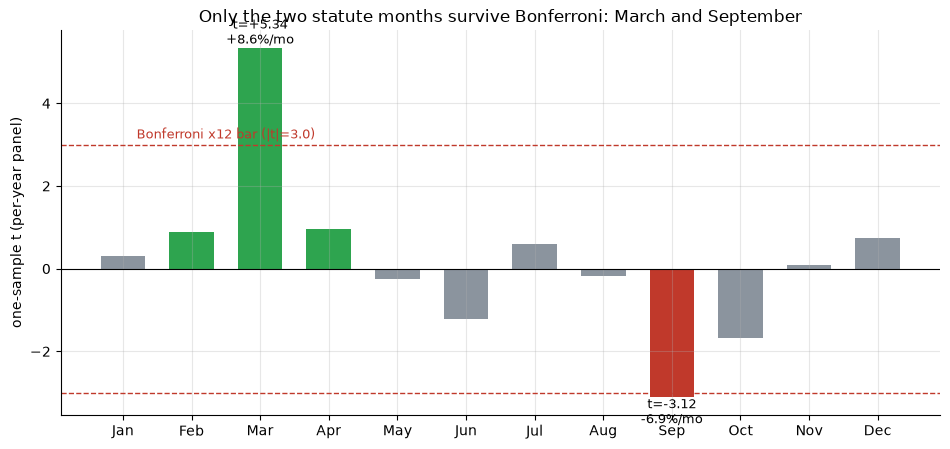

{'Jan': 0.31, 'Feb': 0.88, 'Mar': 5.34, 'Apr': 0.95, 'May': -0.26, 'Jun': -1.21, 'Jul': 0.59, 'Aug': -0.19, 'Sep': -3.12, 'Oct': -1.67, 'Nov': 0.09, 'Dec': 0.73}


In [2]:
if HAVE_REAL:
    mt = st.month_table(EX)
    tvals = mt['t'].tolist(); means = mt['mean_pct'].tolist()
else:
    tvals = [m[2] for m in R['months']]; means = [m[1] for m in R['months']]
names = [m[0] for m in R['months']]
cols = [GREEN if n in ('Feb','Mar','Apr') else (RED if n=='Sep' else GREY) for n in names]
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.bar(names, tvals, color=cols, width=.65)
ax.axhline(0, c='k', lw=.8)
for y in (3.0, -3.0): ax.axhline(y, ls='--', c=RED, lw=1)
ax.annotate('Bonferroni x12 bar (|t|=3.0)', (0.2, 3.15), color=RED, fontsize=9)
for i, (t, v) in enumerate(zip(tvals, means)):
    if abs(t) >= 3.0: ax.annotate(f't={t:+.2f}\n{v:+.1f}%/mo', (i, t), ha='center',
                                  va='bottom' if t>0 else 'top', fontsize=9)
ax.set_ylabel('one-sample t (per-year panel)')
ax.set_title('Only the two statute months survive Bonferroni: March and September')
plt.tight_layout(); plt.show()
print({n: round(t,2) for n, t in zip(names, tvals)})

> 💡 In plain words: out of twelve months, exactly two clear the multiple-testing bar — **March (t = +5.34)**, the panic-run into the May-1 deadline, and **September (t = -3.12)**, the switch-back. That's the statute's fingerprint, not a data-mined calendar.

### 4b · The per-year panel — the primary test

Each dot is one year's cumulative Feb–Apr excess (spot proxy). The Welch t across the yearly window-vs-rest pairs is the headline statistic.

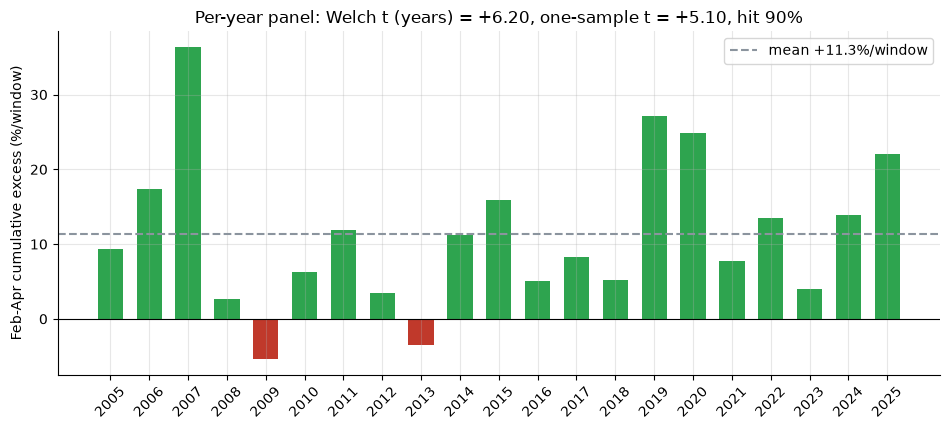

mean window +11.30%  Welch t +6.20  t +5.10  hit 90.5%


In [3]:
if HAVE_REAL:
    ws = st.window_stats(EX, months=data.RUNUP_MONTHS)
    pan = ws['panel']['win_sum'] * 100
    yrs, vals = pan.index.tolist(), pan.tolist()
    wt, t1, hit = ws['welch_t_years'], ws['t_win_sum'], ws['hit_rate']*100
else:
    yrs = list(range(2006, 2027)); vals = [R['win_sum']]*21
    wt, t1, hit = R['welch_years'], R['t_win'], R['hit']
fig, ax = plt.subplots(figsize=(9.6, 4.4))
ax.bar([str(y) for y in yrs], vals, color=[GREEN if v>0 else RED for v in vals], width=.65)
ax.axhline(0, c='k', lw=.8)
ax.axhline(np.mean(vals), ls='--', c=GREY, label=f'mean {np.mean(vals):+.1f}%/window')
ax.set_ylabel('Feb-Apr cumulative excess (%/window)')
ax.set_title(f'Per-year panel: Welch t (years) = {wt:+.2f}, one-sample t = {t1:+.2f}, hit {hit:.0f}%')
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print(f'mean window {np.mean(vals):+.2f}%  Welch t {wt:+.2f}  t {t1:+.2f}  hit {hit:.1f}%')

> 💡 In plain words: **+11.3% per spring window**, positive in 19 of 21 years, Welch **t = 6.20** — far past the desk's t ≥ 2 bar. On the spot proxy, this is about as real as a calendar effect gets.

### 4c · Robustness — window variants + halves

A statute-dated effect shouldn't care exactly where we draw the window, and shouldn't live in one decade.

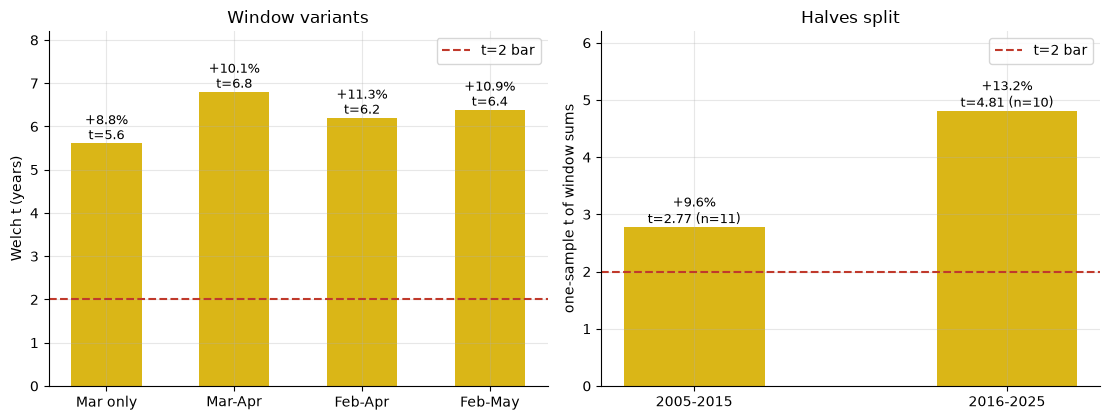

variants: [('Mar only', 8.78, 5.61), ('Mar-Apr', 10.14, 6.8), ('Feb-Apr', 11.3, 6.2), ('Feb-May', 10.91, 6.38)]
halves  : [('2005-2015', np.float64(9.6), 2.77, 11), ('2016-2025', np.float64(13.18), 4.81, 10)]


In [4]:
if HAVE_REAL:
    rob = []
    for label, mos in (('Mar only', (3,)), ('Mar-Apr', (3,4)), ('Feb-Apr', (2,3,4)), ('Feb-May', (2,3,4,5))):
        w2 = st.window_stats(EX, months=mos)
        rob.append((label, w2['win_sum_pct'], w2['t_win_sum'], w2['welch_t_years']))
    pan = st.window_stats(EX, months=data.RUNUP_MONTHS)['panel']
    halves = [('2005-2015', pan.loc[:2015]['win_sum']*100), ('2016-2025', pan.loc[2016:]['win_sum']*100)]
    hv = [(lab, s.mean(), st.ttest_vs_zero(s.values/100), len(s)) for lab, s in halves]
else:
    rob = [(r[0], r[1], r[2], r[3]) for r in R['robust']]
    hv = [(h[0], h[1], h[2], h[3]) for h in R['halves']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.3))
a1.bar([r[0] for r in rob], [r[3] for r in rob], color=AMBER, width=.55)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i, r in enumerate(rob): a1.annotate(f'{r[1]:+.1f}%\nt={r[3]:.1f}', (i, r[3]), ha='center', va='bottom', fontsize=9)
a1.set_ylabel('Welch t (years)'); a1.set_ylim(0, 8.2); a1.set_title('Window variants'); a1.legend()
a2.bar([h[0] for h in hv], [h[2] for h in hv], color=AMBER, width=.45)
a2.axhline(2, ls='--', c=RED, label='t=2 bar')
for i, h in enumerate(hv): a2.annotate(f'{h[1]:+.1f}%\nt={h[2]:.2f} (n={h[3]})', (i, h[2]), ha='center', va='bottom', fontsize=9)
a2.set_ylabel('one-sample t of window sums'); a2.set_ylim(0, 6.2); a2.set_title('Halves split'); a2.legend()
plt.tight_layout(); plt.show()
print('variants:', [(r[0], round(r[1],2), round(r[3],2)) for r in rob])
print('halves  :', [(h[0], round(h[1],2), round(h[2],2), h[3]) for h in hv])

> 💡 In plain words: every window variant sits at Welch t ≥ 5.6, and each half clears the bar alone (t = 2.77 and 4.81). No window-snooping, no single-regime artefact.

### 4d · The third axis — the paired roll-gap test

Per year, same window: cumulative log return of the **holder** (UGA) minus the **spliced chain** (RB=F). If the curve pre-prices the statute, this gap is negative in the run-up and positive in September. Paired, so the oil level cancels exactly.

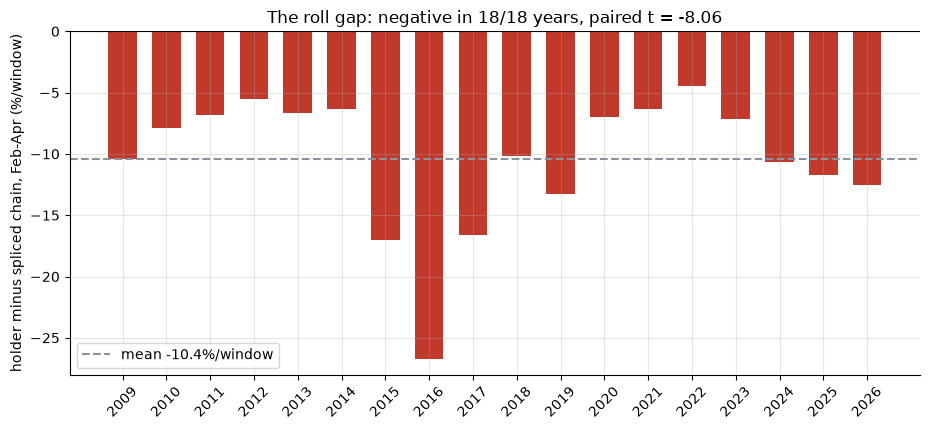

mean gap -10.40%/window  paired t -8.06  negative 100% of years


In [5]:
if HAVE_REAL:
    rg = st.roll_gap_stats(MRET, months=data.RUNUP_MONTHS)
    pan = rg['panel']['gap_sum'] * 100
    yrs, vals = pan.index.tolist(), pan.tolist()
    gt = rg['t']
else:
    yrs = list(range(2009, 2027)); vals = [R['roll_gap']]*18; gt = R['roll_t']
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.bar([str(y) for y in yrs], vals, color=RED, width=.65)
ax.axhline(0, c='k', lw=.8)
ax.axhline(np.mean(vals), ls='--', c=GREY, label=f'mean {np.mean(vals):+.1f}%/window')
ax.set_ylabel('holder minus spliced chain, Feb-Apr (%/window)')
ax.set_title(f'The roll gap: negative in {sum(v<0 for v in vals)}/{len(vals)} years, paired t = {gt:+.2f}')
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print(f'mean gap {np.mean(vals):+.2f}%/window  paired t {gt:+.2f}  negative {100*np.mean([v<0 for v in vals]):.0f}% of years')

> 💡 In plain words: **every single spring since UGA exists** (18/18 years), holding the front month cost about **10 points** of the 16-point window gain — paired **t = -8.06**. And in September the sign flips (**+6.38%**, t = +4.95): the curve refunds the switch-back it already discounted. The seasonal is a property of the *curve shape*, not of holding gasoline. (The gap also carries UGA's ~0.75%/yr fee and T-bill collateral interest — second-order beside a 10-point window gap.)

### 4e · Tradability — the investable legs, with costs

Two honest vehicles: the dollar-neutral **investable crack** (long UGA / short CL, monthly rebalanced) and the **long-only UGA window overlay** (one round trip/yr, one-way bps × NAV, then minus the window T-bill for the excess-vs-cash race).

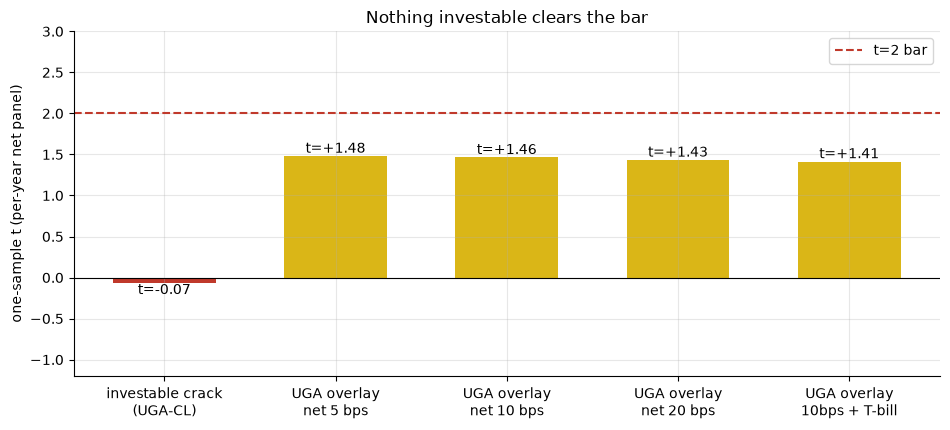

investable crack: -0.18%/window t=-0.07; overlay ts: [1.48, 1.46, 1.43, 1.41]


In [6]:
if HAVE_REAL:
    exi = st.excess_series(MRET, long='UGA', short='CL=F')
    wsi = st.window_stats(exi, months=data.RUNUP_MONTHS)
    inv = (wsi['win_sum_pct'], wsi['t_win_sum'])
    ov = [st.overlay_stats(MRET, cost_bps=cb) for cb in (5.0, 10.0, 20.0)]
    oc = st.overlay_excess_cash(MRET, data.tbill_monthly(PX), cost_bps=10.0)
    bars = [inv[1]] + [o['t_net'] for o in ov] + [oc['t']]
    labs = ['investable crack\n(UGA-CL)'] + [f'UGA overlay\nnet {o["cost_bps"]:.0f} bps' for o in ov] + ['UGA overlay\n10bps + T-bill']
else:
    inv = (R['inv_win_sum'], R['inv_t'])
    bars = [R['inv_t']] + [o[3] for o in R['overlay']] + [R['overlay_xcash_t']]
    labs = ['investable crack\n(UGA-CL)', 'UGA overlay\nnet 5 bps', 'UGA overlay\nnet 10 bps', 'UGA overlay\nnet 20 bps', 'UGA overlay\n10bps + T-bill']
fig, ax = plt.subplots(figsize=(9.6, 4.4))
ax.bar(labs, bars, color=[RED, AMBER, AMBER, AMBER, AMBER], width=.6)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
ax.axhline(0, c='k', lw=.8)
for i, t in enumerate(bars): ax.annotate(f't={t:+.2f}', (i, t), ha='center', va='bottom' if t>0 else 'top')
ax.set_ylabel('one-sample t (per-year net panel)'); ax.set_ylim(-1.2, 3.0)
ax.set_title('Nothing investable clears the bar')
ax.legend(); plt.tight_layout(); plt.show()
print(f'investable crack: {inv[0]:+.2f}%/window t={inv[1]:+.2f}; overlay ts:', [round(b,2) for b in bars[1:]])

> 💡 In plain words: the dollar-neutral version is a coin flip (**-0.18%/window, t = -0.07**, hit 47%). The long-only window is +9.4% gross on average but t ≈ 1.4 — it's unhedged energy beta with 2008/2020-sized wrecks in the panel, and it fails the bar at every cost level (costs barely matter: one round trip a year). **MIRAGE** is the only honest stamp.

### 4f · Faithful-engine control — we know the truth here

Synthetic world with a planted window seasonal (`amp`, mirrored −amp in Sep) and a planted holder drag (`roll_drag`). Mean t over 20 seeds; the null must stay quiet on every detector. *(Machinery proof only — never cited as market evidence.)*

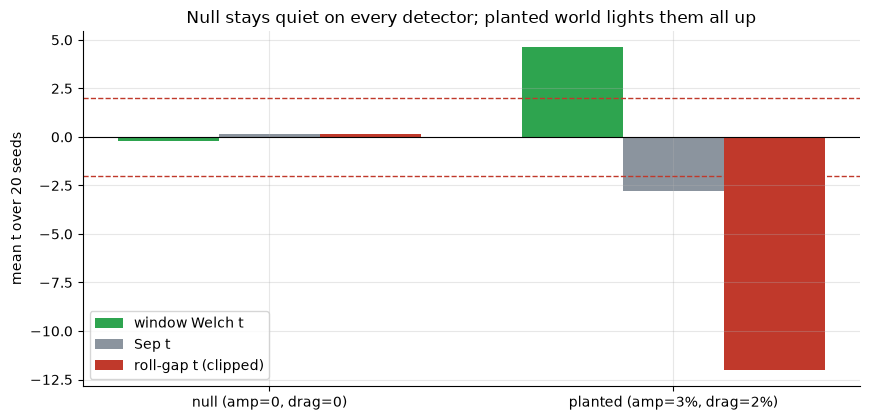

amp=0% drag=0%: window t=-0.22  Sep t=+0.16  roll-gap t=+0.16
amp=3% drag=2%: window t=+4.61  Sep t=-2.76  roll-gap t=-42.35


In [7]:
rows = []
for amp, drag in ((0.0, 0.0), (0.03, 0.02)):
    wt, st9, gt = [], [], []
    for s in range(20):
        m = data.synthetic_world(amp=amp, roll_drag=drag, seed=639 + s)
        exs = st.excess_series(m)
        wt.append(st.window_stats(exs, months=data.RUNUP_MONTHS)['welch_t_years'])
        st9.append(st.single_month_stats(exs, month=data.SWITCHBACK_MONTH)['t'])
        gt.append(st.roll_gap_stats(m, months=data.RUNUP_MONTHS)['t'])
    rows.append((amp, drag, np.mean(wt), np.mean(st9), np.mean(gt)))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
x = np.arange(2); w = 0.25
ax.bar(x - w, [r[2] for r in rows], w, color=GREEN, label='window Welch t')
ax.bar(x, [r[3] for r in rows], w, color=GREY, label='Sep t')
ax.bar(x + w, [np.clip(r[4], -12, 12) for r in rows], w, color=RED, label='roll-gap t (clipped)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(['null (amp=0, drag=0)', 'planted (amp=3%, drag=2%)'])
ax.set_ylabel('mean t over 20 seeds')
ax.set_title('Null stays quiet on every detector; planted world lights them all up')
ax.legend(); plt.tight_layout(); plt.show()
for r in rows: print(f'amp={r[0]*100:.0f}% drag={r[1]*100:.0f}%: window t={r[2]:+.2f}  Sep t={r[3]:+.2f}  roll-gap t={r[4]:+.2f}')

> 💡 In plain words: with nothing planted, every detector reads ≈0 (window -0.22, Sep +0.16, gap +0.16); plant a 3%/mo seasonal + 2%/mo holder drag and they light up (window +4.61, Sep -2.76, gap -42.4). The machinery measures what it claims to.

## 5 · The verdict

- **Signal `REAL`** — Feb–Apr window **+11.30%** cumulative excess, Welch **t = 6.20** across 21 yearly pairs (one-sample t = 5.10, hit 90.5%); Mar (+8.62%/mo, t = +5.34) and Sep (-6.88%/mo, t = -3.12) are the only Bonferroni-×12 survivors — the statute's own two months; both halves independently clear t ≥ 2. Spot-proxy label on the splice, said out loud.
- **Tradability `MIRAGE`** — investable crack -0.18%/window at t = -0.07; the roll gap hands the seasonal to the curve (-10.40%/window, t = -8.06, negative 18/18 years); long-only UGA overlay t ≈ 1.46 net of costs and cash. Nothing clears the bar.
- **Curve prices it? `CONFIRMED`** — the paired gap is the statute's mirror in the curve: -10.40% charged in the spring rolls, +6.38% refunded in September. A seasonal you can see — priced so you can't buy it.

## 6 · Going further

- **The general law:** for storable seasonal commodities, deterministic seasonals migrate into the forward curve (Borovkova & Geman 2006). The tradable residual is whatever the curve *mis*-prices — weather surprises, refinery outages — none of it calendar-dated.
- **Fixed-maturity variants:** a fixed summer contract (e.g., buy the May RB crack in January and hold, no rolls) tests whether the *curve level* itself drifts seasonally — a different, subtler claim; yfinance's chain data can't cleanly separate it, a CME-data follow-up could.
- **Named siblings:** [226-crude-seasonality](../../226-crude-seasonality/README.md) (WTI outright by month — weak, regime-dependent), [306-crack-spread](../../306-crack-spread/README.md) (the crack *level* as a refiner-stock timer — none). This study is the third axis of that triangle: the *dated calendar* on the *spread*, and who pockets it.

*The reproducible core is offline and deterministic; the signal is the statute window on the RB−CL excess, the myth-check is the paired UGA-vs-splice roll gap. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*